In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# !find /content -type f -iname "*.jpg" -delete

In [5]:
!tar -xzf /content/drive/MyDrive/rafdb.tar.gz -C /content/ #extraction

In [6]:
!ls /content            # Lecture des fichiers à l'intérieur du dossier "rafdb.tar.gz"
!ls /content/archive
!ls /content/archive/RAF-DB
!ls /content/data
!ls /content
!ls /content/archive
!ls /content/archive/RAF-DB

archive  data  drive  get_dataset.py  sample_data
FER2013  RAF-DB
test  test_RAF_labels.csv  train  train_RAF_labels.csv
data
archive  data  drive  get_dataset.py  sample_data
FER2013  RAF-DB
test  test_RAF_labels.csv  train  train_RAF_labels.csv


In [7]:
import torch
import torch.nn as nn
from torch.nn import Linear, Conv2d, BatchNorm1d, BatchNorm2d, PReLU, Sequential, Module
from torchvision.transforms import transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import torch.optim as optim
from tqdm import tqdm
from sklearn.model_selection import ParameterGrid

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # mps GPU pour Mac
# device = torch.device("cpu")
print(f"Using device: {device}")

Using device: cuda


In [8]:
import os
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset
import torch

class RAFDBDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.labels = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        img_name = os.path.join(self.img_dir, self.labels.iloc[idx, 0])
        image = Image.open(img_name)
        label = self.labels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)

        return image, label

In [9]:
from get_dataset import GiMeFiveDataset

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    # transforms.RandomErasing(scale=(0.02,0.25)),
])

rafdb_dataset_train = GiMeFiveDataset(csv_file='/content/archive/RAF-DB/train_RAF_labels.csv',
                            img_dir='/content/archive/RAF-DB/train/',
                            transform=transform)

# rafdb_dataset_train = GiMeFiveDataset(csv_file='/content/archive/FER2013/train_FER_labels.csv',
#                             img_dir='/content/archive/FER2013/train/',
#                             transform=transform)

# rafdb_dataset_train = GiMeFiveDataset(csv_file='/content/data/train_labels.csv',
#                             img_dir='/content/data/train/',
#                             transform=transform)
data_train_loader = DataLoader(rafdb_dataset_train, batch_size=16, shuffle=True, num_workers=4)
train_image, train_label = next(iter(data_train_loader))
print(f"Train batch: image shape {train_image.shape}, labels shape {train_label.shape}")

rafdb_dataset_vali = GiMeFiveDataset(csv_file='/content/data/data/valid_labels.csv', # modification du chemin
                            img_dir='/content/data/data/valid/',
                            transform=transform)

data_vali_loader = DataLoader(rafdb_dataset_vali, batch_size=16, shuffle=False, num_workers=0)
vali_image, vali_label = next(iter(data_vali_loader))
print(f"Vali batch: image shape {vali_image.shape}, labels shape {vali_label.shape}")

rafdb_dataset_test = GiMeFiveDataset(csv_file='/content/archive/RAF-DB/test_RAF_labels.csv',
                            img_dir='/content/archive/RAF-DB/test/',
                            transform=transform)

# rafdb_dataset_test = GiMeFiveDataset(csv_file='/content/archive/FER2013/test_FER_labels.csv',
#                             img_dir='/content/archive/FER2013/test/',
#                             transform=transform)

# rafdb_dataset_test = GiMeFiveDataset(csv_file='/content/data/test_labels.csv',
#                             img_dir='/content/data/test/',
#                             transform=transform)
data_test_loader = DataLoader(rafdb_dataset_test, batch_size=16, shuffle=False, num_workers=0)
test_image, test_label = next(iter(data_test_loader))
print(f"Test batch: image shape {test_image.shape}, labels shape {test_label.shape}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Train batch: image shape torch.Size([16, 3, 64, 64]), labels shape torch.Size([16])
Vali batch: image shape torch.Size([16, 3, 64, 64]), labels shape torch.Size([16])
Test batch: image shape torch.Size([16, 3, 64, 64]), labels shape torch.Size([16])


In [10]:
class SEBlock(nn.Module): # Squeeze-and-Excitation (SE) blocks apply channel-wise attention.
    def __init__(self, input_channels, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(input_channels, input_channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(input_channels // reduction, input_channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

In [11]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, padding=0),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

In [12]:

# class EmotionClassifier(nn.Module):
#     def __init__(self):
#         super(EmotionClassifier, self).__init__()
#         self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
#         self.bn1 = nn.BatchNorm2d(64)
#         self.relu = nn.ReLU(inplace=True)
#         self.se1 = SEBlock(64)

#         self.res_block1 = ResidualBlock(64, 128, stride=2)
#         self.res_block2 = ResidualBlock(128, 256, stride=2)
#         self.res_block3 = ResidualBlock(256, 512, stride=2)
#         self.res_block4 = ResidualBlock(512, 1024, stride=2)
#         self.res_block5 = ResidualBlock(1024, 2048, stride=2)

#         self.pool = nn.AdaptiveAvgPool2d((1, 1))
#         self.fc1 = nn.Linear(2048, 4096)
#         self.fc2 = nn.Linear(4096, 2048)
#         self.dropout1 = nn.Dropout(0.5)
#         self.fc3 = nn.Linear(2048, 6)

#     def forward(self, x):
#         x = self.relu(self.bn1(self.conv1(x)))
#         x = self.se1(x)

#         x = self.res_block1(x)
#         x = self.res_block2(x)
#         x = self.res_block3(x)
#         x = self.res_block4(x)
#         x = self.res_block5(x)

#         x = self.pool(x)
#         x = x.view(x.size(0), -1)
#         x = F.relu(self.fc1(x))
#         x = self.dropout1(x)
#         x = F.relu(self.fc2(x))
#         x = self.fc3(x)
#         return x

# model = EmotionClassifier().to(device)

In [13]:
class EmotionClassifier(nn.Module):
    def __init__(self):
        super(EmotionClassifier, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(256)
        self.conv4 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(512)
        self.conv5 = nn.Conv2d(512, 1024, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(1024)

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc1 = nn.Linear(1024, 2048)
        self.fc2 = nn.Linear(2048, 1024)
        self.dropout1 = nn.Dropout(0.2)
        self.dropout2 = nn.Dropout(0.5)
        self.fc3 = nn.Linear(1024, 6)

    def forward(self, x): # (batch_size, channels=3, 64, 64)
        x = F.relu(self.bn1(self.conv1(x))) # (batch_size, 64, 64, 64)
        x = F.max_pool2d(x, 2) # (batch_size, 64, 32, 32)
        x = self.dropout1(x)
        x = F.relu(self.bn2(self.conv2(x))) # (batch_size, 128, 32, 32)
        x = F.max_pool2d(x, 2) # (batch_size, 128, 16, 16)
        x = self.dropout1(x)
        x = F.relu(self.bn3(self.conv3(x))) # (batch_size, 256, 16, 16)
        x = F.max_pool2d(x, 2) # (batch_size, 256, 8, 8)
        x = self.dropout1(x)
        x = F.relu(self.bn4(self.conv4(x))) # (batch_size, 512, 8, 8)
        x = F.max_pool2d(x, 2) # (batch_size, 512, 4, 4)
        x = self.dropout1(x)
        x = F.relu(self.bn5(self.conv5(x))) # (batch_size, 1024, 4, 4)
        x = F.max_pool2d(x, 2) # (batch_size, 1024, 2, 2)
        # x = self.dropout1(x)

        x = self.pool(x) # (batch_size, 1024, 1, 1)
        x = x.view(x.size(0), -1) # (batch_size, 1024) # Flatten
        x = F.relu(self.fc1(x)) # (batch_size, 2048)
        x = self.dropout2(x) # (batch_size, 2048)
        x = F.relu(self.fc2(x)) # (batch_size, 1024)
        x = self.fc3(x) # (batch_size, 6)
        return x

model = EmotionClassifier().to(device)

In [14]:
# model.load_state_dict(torch.load('best_baseline.pth', map_location=device))
# model.eval()

In [15]:
class Baseline(nn.Module):
    def __init__(self):
        super(Baseline, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(256)
        self.conv4 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(512)
        # self.conv5 = nn.Conv2d(512, 1024, kernel_size=3, padding=1)
        # self.bn5 = nn.BatchNorm2d(1024)

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc1 = nn.Linear(512, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.dropout1 = nn.Dropout(0.2)
        self.dropout2 = nn.Dropout(0.5)
        self.fc3 = nn.Linear(512, 6)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = F.relu(self.bn4(self.conv4(x)))
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        # x = F.relu(self.bn5(self.conv5(x)))
        # x = F.max_pool2d(x, 2)
        # x = self.dropout1(x)

        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = Baseline().to(device)

In [16]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params}")

Total trainable parameters: 2606086


In [17]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F

# class BasicBlock(nn.Module):
#     expansion = 1

#     def __init__(self, in_planes, planes, stride=1):
#         super(BasicBlock, self).__init__()
#         self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
#         self.bn1 = nn.BatchNorm2d(planes)
#         self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
#         self.bn2 = nn.BatchNorm2d(planes)

#         self.shortcut = nn.Sequential()
#         if stride != 1 or in_planes != self.expansion * planes:
#             self.shortcut = nn.Sequential(
#                 nn.Conv2d(in_planes, self.expansion * planes, kernel_size=1, stride=stride, bias=False),
#                 nn.BatchNorm2d(self.expansion * planes)
#             )

#     def forward(self, x):
#         out = F.relu(self.bn1(self.conv1(x)))
#         out = self.bn2(self.conv2(out))
#         out += self.shortcut(x)
#         out = F.relu(out)
#         return out

# class ResNet(nn.Module):
#     def __init__(self, block, num_blocks, num_classes=6):
#         super(ResNet, self).__init__()
#         self.in_planes = 64

#         self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
#         self.bn1 = nn.BatchNorm2d(64)
#         self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
#         self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
#         self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
#         self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)
#         self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
#         self.fc = nn.Linear(512 * block.expansion, num_classes)

#     def _make_layer(self, block, planes, num_blocks, stride):
#         strides = [stride] + [1]*(num_blocks-1)
#         layers = []
#         for stride in strides:
#             layers.append(block(self.in_planes, planes, stride))
#             self.in_planes = planes * block.expansion
#         return nn.Sequential(*layers)

#     def forward(self, x):
#         out = F.relu(self.bn1(self.conv1(x)))
#         out = self.layer1(out)
#         out = self.layer2(out)
#         out = self.layer3(out)
#         out = self.layer4(out)
#         out = self.avgpool(out)
#         out = out.view(out.size(0), -1)
#         out = self.fc(out)
#         return out

# def EmotionClassifierResNet18():
#     return ResNet(BasicBlock, [2, 2, 2, 2])

# model = EmotionClassifierResNet18().to(device)


In [18]:
# param_grid = {
#     'lr': [0.1, 0.01, 0.001, 0.0001],
#     'batch_size': [8, 16, 32, 64],
# }
# grid = ParameterGrid(param_grid)
# results = []

In [19]:
# for params in grid: # Hyperparameter tuning
#     data_train_loader = DataLoader(rafdb_dataset_train, batch_size=params['batch_size'], shuffle=True, num_workers=4)
#     data_vali_loader = DataLoader(rafdb_dataset_vali, batch_size=params['batch_size'], shuffle=False, num_workers=0)

#     model = EmotionClassifier().to(device)
#     optimizer = optim.Adam(model.parameters(), lr=params['lr'])
#     criterion = nn.CrossEntropyLoss()

#     best_val_acc = 0
#     num_epochs = 15

#     for epoch in range(num_epochs):
#         model.train()
#         for i, data in enumerate(tqdm(data_train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"), 0):
#             inputs, labels = data[0].to(device), data[1].to(device)
#             optimizer.zero_grad()
#             outputs = model(inputs)
#             loss = criterion(outputs, labels)
#             loss.backward()
#             optimizer.step()

#     model.eval()
#     val_correct = 0
#     val_total = 0
#     with torch.no_grad():
#         for data in data_vali_loader:
#             inputs, labels = data[0].to(device), data[1].to(device)
#             outputs = model(inputs)
#             _, predicted = torch.max(outputs.data, 1)
#             val_total += labels.size(0)
#             val_correct += (predicted == labels).sum().item()

#     val_acc = val_correct / val_total
#     best_val_acc = max(best_val_acc, val_acc)

#     results.append({
#         'lr': params['lr'],
#         'batch_size': params['batch_size'],
#         'best_val_acc': best_val_acc,
#     })

# for result in results:
#     print(f"LR: {result['lr']}, Batch Size: {result['batch_size']}, Best Val Acc: {result['best_val_acc']}")

# best_params = max(results, key=lambda x: x['best_val_acc'])
# print(f"Best params: {best_params}")

In [20]:
criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.parameters(), lr=0.001)
# optimizer = optim.Adam(model.parameters(), lr=0.001, amsgrad=True)
# optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)
# optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, nesterov=True)
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)


patience = 15
best_val_acc = 0
patience_counter = 0

num_epochs = 80

In [21]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
test_losses = []
test_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for data in tqdm(data_train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        inputs, labels = data[0].to(device), data[1].to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(data_train_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    model.eval()
    test_running_loss = 0.0
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for data in data_test_loader:
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()

    test_loss = test_running_loss / len(data_test_loader)
    test_acc = test_correct / test_total
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for data in data_vali_loader:
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(data_vali_loader)
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}, Train Loss: {train_loss}, Train Accuracy: {train_acc}, Test Loss: {test_loss}, Test Accuracy: {test_acc}, Validation Loss: {val_loss}, Validation Accuracy: {val_acc}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        patience_counter += 1
        print(f"No improvement in validation accuracy for {patience_counter} epochs.")

    if patience_counter > patience:
        print("Stopping early due to lack of improvement in validation accuracy.")
        break

Epoch 1/80:   0%|          | 0/610 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Epoch 1/80: 100%|██████████| 610/610 [00:11<00:00, 55.02it/s]


Epoch 1, Train Loss: 1.4001735393141137, Train Accuracy: 0.4923045351939257, Test Loss: 1.3864916936556497, Test Accuracy: 0.49602010892333476, Validation Loss: 2.150790600400222, Validation Accuracy: 0.1686143572621035


Epoch 2/80: 100%|██████████| 610/610 [00:09<00:00, 65.82it/s]


Epoch 2, Train Loss: 1.3635031337620782, Train Accuracy: 0.49445926533962653, Test Loss: 1.460914096434911, Test Accuracy: 0.4964390448261416, Validation Loss: 2.485657710778086, Validation Accuracy: 0.1686143572621035
No improvement in validation accuracy for 1 epochs.


Epoch 3/80: 100%|██████████| 610/610 [00:08<00:00, 68.57it/s]


...

Epoch 78, Train Loss: 0.294520807104399, Train Accuracy: 0.8961625282167043, Test Loss: 0.52049135467348, Test Accuracy: 0.8374528697109342, Validation Loss: 0.9256220565814721, Validation Accuracy: 0.7345575959933222


Epoch 79/80: 100%|██████████| 610/610 [00:09<00:00, 64.16it/s]


Epoch 79, Train Loss: 0.2988067334868991, Train Accuracy: 0.89605992201929, Test Loss: 0.5037409224050741, Test Accuracy: 0.8395475492249685, Validation Loss: 0.8528724569631251, Validation Accuracy: 0.7262103505843072
No improvement in validation accuracy for 1 epochs.


Epoch 80/80: 100%|██████████| 610/610 [00:09<00:00, 65.29it/s]


Epoch 80, Train Loss: 0.2859904139113735, Train Accuracy: 0.8975990149805049, Test Loss: 0.6852719852887094, Test Accuracy: 0.7993297025555091, Validation Loss: 1.133281882656248, Validation Accuracy: 0.6811352253756261
No improvement in validation accuracy for 2 epochs.


In [22]:
print("len(train_losses) =", len(train_losses))
print("len(test_losses) =", len(test_losses))
print("len(val_losses) =", len(val_losses))
print("len(train_accuracies) =", len(train_accuracies))
print("len(test_accuracies) =", len(test_accuracies))
print("len(val_accuracies) =", len(val_accuracies))

print("train_losses[:5] =", train_losses[:5])
print("val_losses[:5] =", val_losses[:5])
print("test_losses[:5] =", test_losses[:5])

len(train_losses) = 80
len(test_losses) = 80
len(val_losses) = 80
len(train_accuracies) = 80
len(test_accuracies) = 80
len(val_accuracies) = 80
train_losses[:5] = [1.4001735393141137, 1.3635031337620782, 1.3338550598894963, 1.2778262717802016, 1.2106816458897514]
val_losses[:5] = [2.150790600400222, 2.485657710778086, 2.290670451365019, 2.811199062748959, 2.670509696006775]
test_losses[:5] = [1.3864916936556497, 1.460914096434911, 1.3713123927513757, 1.5788600291560093, 1.5209205316007137]


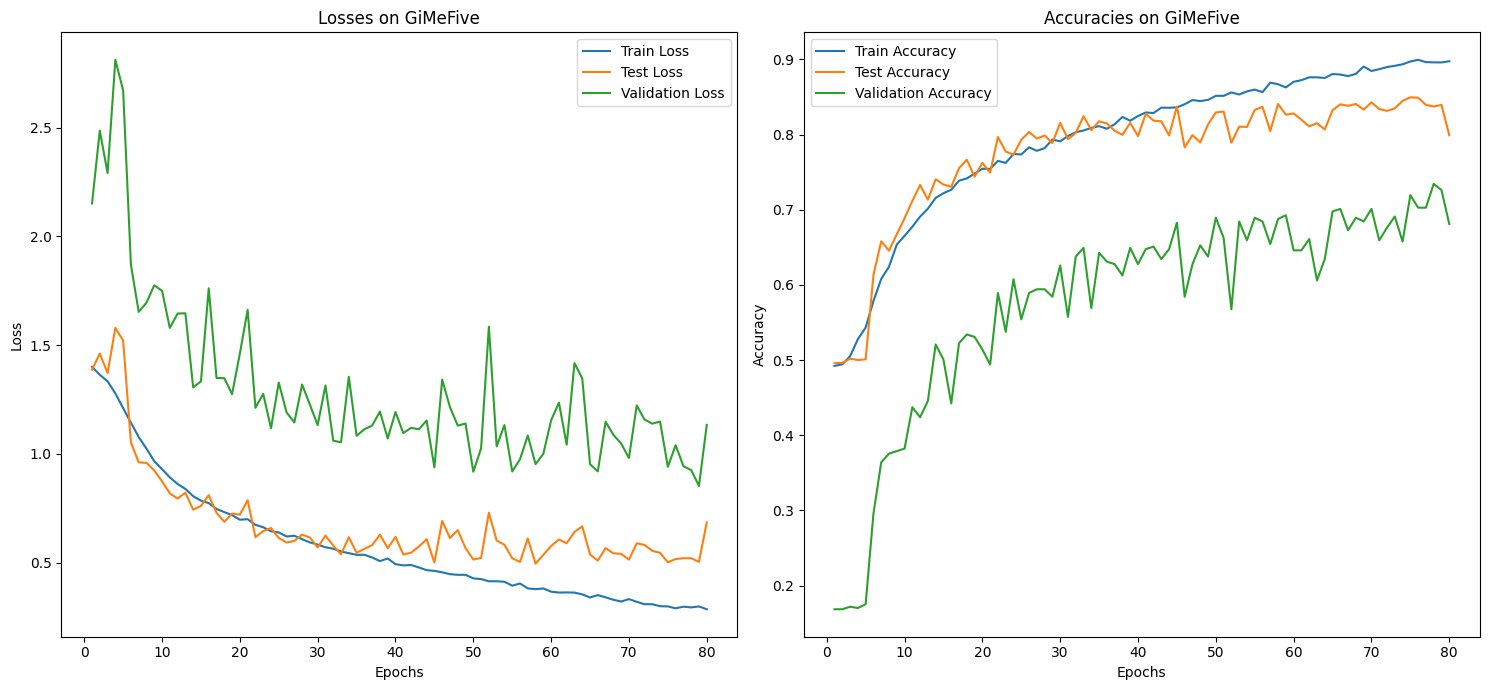

In [23]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, test_losses, label='Test Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Losses on GiMeFive')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, test_accuracies, label='Test Accuracy')
plt.plot(epochs, val_accuracies, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracies on GiMeFive')
plt.legend()

plt.tight_layout()
plt.show()

In [25]:
df = pd.DataFrame({
    'Epoch': range(1, len(train_losses) + 1),
    'Train Loss': train_losses,
    'Test Loss': test_losses,
    'Validation Loss': val_losses,
    'Train Accuracy': train_accuracies,
    'Test Accuracy': test_accuracies,
    'Validation Accuracy': val_accuracies
})

df.to_csv('result_gimefive.csv', index=False)